# McStas Workflow - Chunk by Chunk
In this example, we will process McStas events chunk by chunk, panel by panel.

## Build Base Workflow

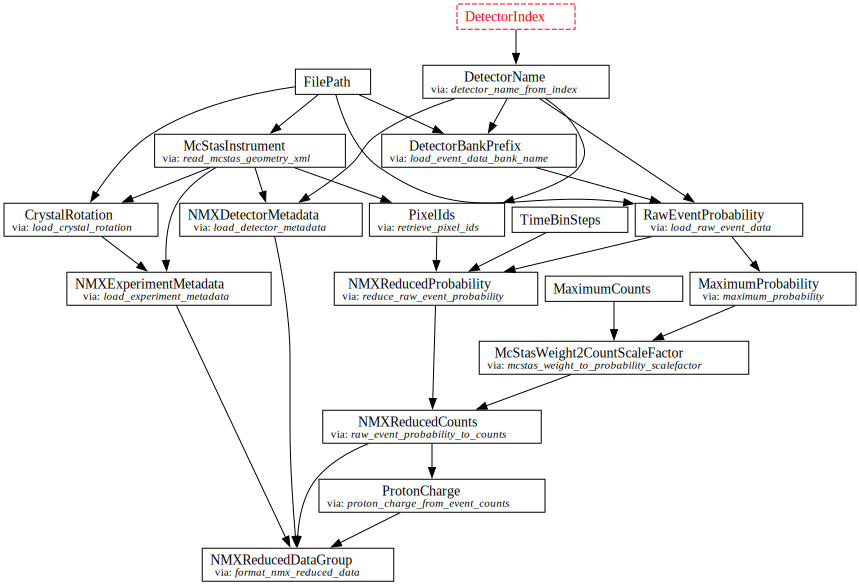

In [1]:
from ess.nmx.mcstas import NMXMcStasWorkflow
from ess.nmx.data import get_small_mcstas
from ess.nmx.mcstas.types import *

wf = NMXMcStasWorkflow()
# Replace with the path to your own file
wf[FilePath] = get_small_mcstas()
wf[MaximumCounts] = 10_000
wf[TimeBinSteps] = 50
wf.visualize(NMXReducedDataGroup, graph_attr={"rankdir": "TD"}, compact=True)

## Compute Raw Data Metadata

`time-of-flight` coordinate and `McStasWeight2CountScaleFactor` should not be different from chunk to chunk.

Therefore we need to compute `TimeBinSteps` and `McStasWeight2CountScaleFactor` before we compute `NMXReducedData`.

It can be done by `ess.reduce.streaming.StreamProcessor`.

In this example, `MinimumTimeOfArrival`, `MaximumTimeOfArrival`, and `MaximumProbability` are recomputed each time a chunk is added to the streaming processor.

`(Min/Max)Accumulator` remembers the previous minimum/maximum value and compute new minimum/maximum value with the new chunk.

``raw_event_data_chunk_generator`` yields a chunk of raw event probability from mcstas h5 file.

This example below process the data chunk by chunk with size: ``CHUNK_SIZE``.

In [2]:
from functools import partial
from ess.reduce.streaming import StreamProcessor, MaxAccumulator, MinAccumulator

# Stream processor building helper
scalefactor_stream_processor = partial(
    StreamProcessor,
    dynamic_keys=(RawEventProbability,),
    target_keys=(NMXRawDataMetadata,),
    accumulators={
        MaximumProbability: MaxAccumulator,
        MaximumTimeOfArrival: MaxAccumulator,
        MinimumTimeOfArrival: MinAccumulator,
    },
)
metadata_wf = wf.copy()

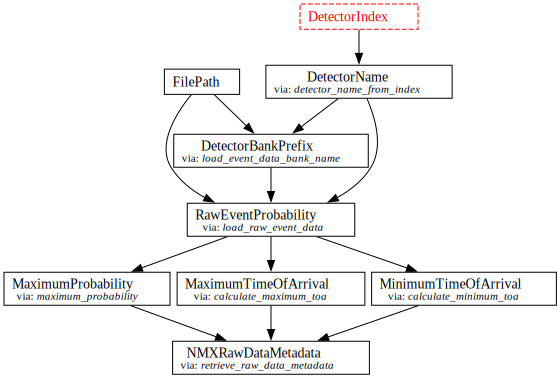

In [3]:
metadata_wf.visualize(NMXRawDataMetadata, graph_attr={"rankdir": "TD"}, compact=True)

In [4]:
from ess.nmx.mcstas.load import (
    raw_event_data_chunk_generator,
    mcstas_weight_to_probability_scalefactor,
)
from ess.nmx.mcstas.streaming import calculate_number_of_chunks
from ipywidgets import IntProgress

CHUNK_SIZE = 10  # Number of event rows to process at once
# Increase this number to speed up the processing
NUM_DETECTORS = 3

# Loop over the detectors
file_path = metadata_wf.compute(FilePath)
raw_data_metadatas = {}

for detector_i in range(0, NUM_DETECTORS):
    temp_wf = metadata_wf.copy()
    temp_wf[DetectorIndex] = detector_i
    detector_name = temp_wf.compute(DetectorName)
    max_chunk_id = calculate_number_of_chunks(
        temp_wf.compute(FilePath), detector_name=detector_name, chunk_size=CHUNK_SIZE
    )
    cur_detector_progress_bar = IntProgress(
        min=0, max=max_chunk_id, description=f"Detector {detector_i}"
    )
    display(cur_detector_progress_bar)

    # Build the stream processor
    processor = scalefactor_stream_processor(temp_wf)
    for da in raw_event_data_chunk_generator(
        file_path=file_path, detector_name=detector_name, chunk_size=CHUNK_SIZE
    ):
        if any(da.sizes.values()) == 0:
            continue
        else:
            results = processor.add_chunk({RawEventProbability: da})
        cur_detector_progress_bar.value += 1
    display(results[NMXRawDataMetadata])
    raw_data_metadatas[detector_i] = results[NMXRawDataMetadata]

# We take the min/maximum values of the scale factor
min_toa = min(meta.min_toa for meta in raw_data_metadatas.values())
max_toa = max(meta.max_toa for meta in raw_data_metadatas.values())
max_probability = max(meta.max_probability for meta in raw_data_metadatas.values())

toa_bin_edges = sc.linspace(dim='t', start=min_toa, stop=max_toa, num=51)
scale_factor = mcstas_weight_to_probability_scalefactor(
    max_counts=wf.compute(MaximumCounts), max_probability=max_probability
)

IntProgress(value=0, description='Detector 0', max=7)

/home/runner/work/ess/ess/packages/essnmx/src/ess/nmx/mcstas/load.py:188: UserWarning: The chunk size may be too small < 10_000_000.
Consider increasing the chunk size for better performance.
Hint: NMX typically expect ~10^8 bins as reduced data.
  _check_chunk_size(chunk_size)


NMXRawDataMetadata(max_probability=<scipp.Variable> ()    float64         [counts]  14.665, min_toa=<scipp.Variable> ()    float64              [s]  0.0972552, max_toa=<scipp.Variable> ()    float64              [s]  0.142863)

IntProgress(value=0, description='Detector 1', max=5)

NMXRawDataMetadata(max_probability=<scipp.Variable> ()    float64         [counts]  14.1429, min_toa=<scipp.Variable> ()    float64              [s]  0.0993471, max_toa=<scipp.Variable> ()    float64              [s]  0.143276)

IntProgress(value=0, description='Detector 2', max=6)

NMXRawDataMetadata(max_probability=<scipp.Variable> ()    float64         [counts]  14.9342, min_toa=<scipp.Variable> ()    float64              [s]  0.0993372, max_toa=<scipp.Variable> ()    float64              [s]  0.145276)

## Compute Metadata

Other metadata does not require any chunk-based computation.

Therefore we export the metadata first and append detector data later.

## Compute Final Output

Now with all the metadata, we can compute the final output chunk by chunk.

We will also compute static parameters in advance so that stream processor does not compute them every time another chunk is added.

We will as well export the reduced data detector by detector.

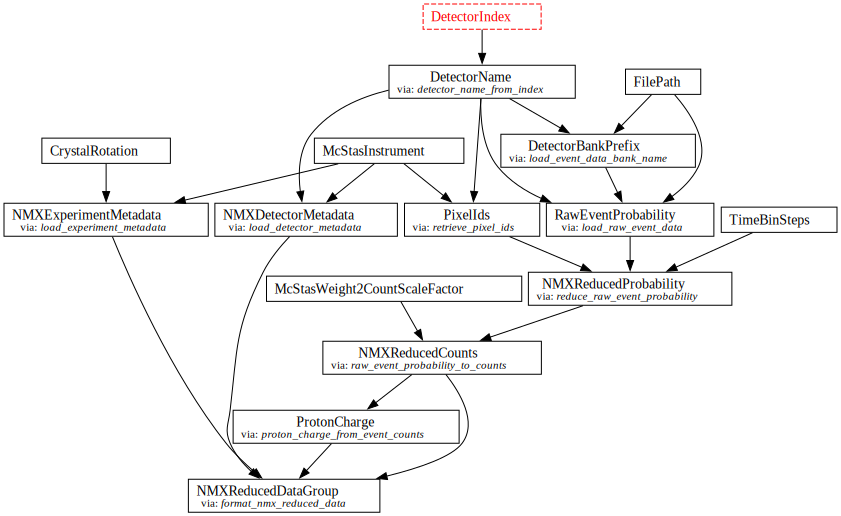

In [5]:
from ess.nmx.mcstas.xml import McStasInstrument

final_wf = wf.copy()
# Set the scale factor and time bin edges
final_wf[McStasWeight2CountScaleFactor] = scale_factor
final_wf[TimeBinSteps] = toa_bin_edges

# Set the crystal rotation manually for now ...
final_wf[CrystalRotation] = sc.vector([0, 0, 0.0], unit='deg')
# Set static info
final_wf[McStasInstrument] = wf.compute(McStasInstrument)
final_wf.visualize(NMXReducedDataGroup, compact=True)

In [6]:
from ess.nmx.mcstas.nexus import NXLauetofWriter


def temp_generator(file_path, detector_name):
    max_chunk_id = calculate_number_of_chunks(
        file_path, detector_name=detector_name, chunk_size=CHUNK_SIZE
    )
    cur_detector_progress_bar = IntProgress(
        min=0, max=max_chunk_id, description=f"Detector {detector_i}"
    )
    display(cur_detector_progress_bar)
    for da in raw_event_data_chunk_generator(
        file_path=file_path, detector_name=detector_name, chunk_size=CHUNK_SIZE
    ):
        yield da
        cur_detector_progress_bar.value += 1


# When a panel is added to the writer,
# the writer will start processing the data from the generator
# and store the results in memory
# The writer will then write the data to the file
# when ``save`` is called
writer = NXLauetofWriter(
    chunk_generator=temp_generator,
    chunk_insert_key=RawEventProbability,
    workflow=final_wf,
    output_filename="test.h5",
    overwrite=True,
    extra_meta={"McStasWeight2CountScaleFactor": scale_factor},
)

In [7]:
for detector_i in range(3):
    display(writer.add_panel(detector_id=detector_i))

IntProgress(value=0, description='Detector 0', max=7)

/home/runner/work/ess/ess/packages/essnmx/src/ess/nmx/mcstas/load.py:188: UserWarning: The chunk size may be too small < 10_000_000.
Consider increasing the chunk size for better performance.
Hint: NMX typically expect ~10^8 bins as reduced data.
  _check_chunk_size(chunk_size)


DataGroup(sizes={'id': 1638400, 't': 50}, keys=[
    counts: DataArray({'id': 1638400, 't': 50}),
    proton_charge: Variable({}),
    crystal_rotation: Variable({}),
    sample_position: Variable({}),
    source_position: Variable({}),
    sample_name: Variable({}),
    fast_axis: Variable({}),
    slow_axis: Variable({}),
    origin_position: Variable({}),
    position: Variable({'id': 1638400}),
    detector_shape: Variable({}),
    x_pixel_size: Variable({}),
    y_pixel_size: Variable({}),
    detector_name: Variable({}),
])

IntProgress(value=0, description='Detector 1', max=5)

DataGroup(sizes={'id': 1638400, 't': 50}, keys=[
    counts: DataArray({'id': 1638400, 't': 50}),
    proton_charge: Variable({}),
    crystal_rotation: Variable({}),
    sample_position: Variable({}),
    source_position: Variable({}),
    sample_name: Variable({}),
    fast_axis: Variable({}),
    slow_axis: Variable({}),
    origin_position: Variable({}),
    position: Variable({'id': 1638400}),
    detector_shape: Variable({}),
    x_pixel_size: Variable({}),
    y_pixel_size: Variable({}),
    detector_name: Variable({}),
])

IntProgress(value=0, description='Detector 2', max=6)

DataGroup(sizes={'id': 1638400, 't': 50}, keys=[
    counts: DataArray({'id': 1638400, 't': 50}),
    proton_charge: Variable({}),
    crystal_rotation: Variable({}),
    sample_position: Variable({}),
    source_position: Variable({}),
    sample_name: Variable({}),
    fast_axis: Variable({}),
    slow_axis: Variable({}),
    origin_position: Variable({}),
    position: Variable({'id': 1638400}),
    detector_shape: Variable({}),
    x_pixel_size: Variable({}),
    y_pixel_size: Variable({}),
    detector_name: Variable({}),
])